# Electricity Hourly Demand — Exploratory Data Analysis

**Dataset:** `data/electricity_hourly_dataset.tsf` (Monash Time Series Forecasting Repository)
**Project phase:** Phase 2 — *Data Understanding & EDA* (see `ROADMAP.md`)

The dataset is an aggregated, hourly version of the UCI *ElectricityLoadDiagrams20112014*
data: **321 hourly time series** of electricity consumption (kW) spanning **2012–2014**.
Every series is equal-length and marked as having no missing values.

## Goals of this notebook
This EDA is the foundation for model design. It answers, concretely, the questions that
determine how we build the forecasting pipeline:

1. **Integrity** — is the data really complete, equal-length and gap-free?
2. **Scale** — how heterogeneous are the series? (drives the normalization strategy)
3. **Seasonality** — what are the dominant periods? (daily 24h, weekly 168h, yearly?)
4. **Autocorrelation / stationarity** — which seasonal period do we use for MASE?
5. **Anomalies** — zeros, spikes, level shifts, near-constant series.
6. **Cross-series structure** — are the series similar enough for a single *global* model?
7. **Modeling implications** — context length, horizon, split, metrics, normalization.

Each section ends with an interpretation. The final section consolidates all findings into
concrete modeling decisions.

---
### Table of contents
1. Setup & configuration
2. TSF parser & data loading
3. Dataset overview & integrity checks
4. Data quality & missingness
5. Global value distribution
6. Per-series scale heterogeneity
7. Aggregate temporal dynamics
8. Multiple-seasonality analysis
9. Autocorrelation (ACF / PACF)
10. Seasonal-trend decomposition (STL / MSTL)
11. Stationarity tests (ADF / KPSS)
12. Outliers & anomalies
13. Cross-series structure (correlation & clustering)
14. Calendar effects
15. Forecasting-readiness summary


## 1. Setup & configuration

In [27]:
import os
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

warnings.filterwarnings("ignore")

# --- Reproducibility ---
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

# --- Plotting style ---
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (12, 4.5)
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["axes.titlesize"] = 12

# --- Pandas display ---
pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 140)
pd.set_option("display.float_format", lambda v: f"{v:,.3f}")

print("pandas", pd.__version__, "| numpy", np.__version__)


pandas 3.0.3 | numpy 2.4.6


In [28]:
# --- Locate project paths robustly (works whether run from repo root or notebooks/) ---
def find_project_root(marker="data/electricity_hourly_dataset.tsf"):
    here = Path.cwd()
    for base in [here, *here.parents]:
        if (base / marker).exists():
            return base
    raise FileNotFoundError(f"Could not locate {marker} from {here}")

PROJECT_ROOT = find_project_root()
DATA_FILE = PROJECT_ROOT / "data" / "electricity_hourly_dataset.tsf"
INTERIM_DIR = PROJECT_ROOT / "data" / "interim"
FIG_DIR = PROJECT_ROOT / "reports" / "figures"
INTERIM_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

# --- Domain constants (kept in sync with ROADMAP.md) ---
DAILY = 24            # hours in a day  -> daily seasonality
WEEKLY = 24 * 7       # 168 hours       -> weekly seasonality
HORIZON = 168         # forecast horizon (1 week), Monash benchmark standard
FREQ = "h"            # hourly

print("Project root:", PROJECT_ROOT)
print("Data file   :", DATA_FILE, f"({DATA_FILE.stat().st_size/1e6:.1f} MB)")


Project root: /Users/mskayacioglu/Documents/projects/energy-demand-forecasting-foundation-models
Data file   : /Users/mskayacioglu/Documents/projects/energy-demand-forecasting-foundation-models/data/electricity_hourly_dataset.tsf (35.9 MB)


## 2. TSF parser & data loading

The `.tsf` (Monash) format has a metadata header (`@attribute`, `@frequency`, `@missing`,
`@equallength`) followed by an `@data` section. Each data row is:

```
<series_name>:<start_timestamp>:<v1>,<v2>,...,<vN>
```

The parser below is general (it reads the declared attributes) but we also keep the fast path
for this equal-length, no-missing dataset. We build two representations:

* **wide** — `DatetimeIndex` (rows) × series (columns); best for temporal aggregation.
* **long** — `unique_id, ds, y`; the tidy format used by `statsforecast`/`neuralforecast`/`chronos`
  in later phases. Saved to `data/interim/` as Parquet.


In [29]:
# Parse a Monash .tsf file -> (metadata: dict, records: list[dict]).
def parse_tsf(path):
    metadata = {"attributes": []}
    records = []
    data_started = False
    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if not line or line.startswith("#"):
                continue
            low = line.lower()
            if not data_started:
                if low.startswith("@attribute"):
                    _, name, typ = line.split(" ", 2)
                    metadata["attributes"].append((name, typ))
                elif low.startswith("@frequency"):
                    metadata["frequency"] = line.split(" ", 1)[1]
                elif low.startswith("@horizon"):
                    metadata["horizon"] = int(line.split(" ", 1)[1])
                elif low.startswith("@missing"):
                    metadata["missing"] = line.split(" ", 1)[1].lower() == "true"
                elif low.startswith("@equallength"):
                    metadata["equallength"] = line.split(" ", 1)[1].lower() == "true"
                elif low.startswith("@data"):
                    data_started = True
                continue
            # data row: name:start_timestamp:v1,v2,...
            parts = line.split(":")
            series_name = parts[0]
            start_ts = parts[1]
            raw_vals = parts[2].split(",")
            values = np.array(
                [np.nan if v in ("?", "") else float(v) for v in raw_vals],
                dtype="float64",
            )
            records.append(
                {"series_name": series_name, "start_timestamp": start_ts, "values": values}
            )
    return metadata, records


metadata, records = parse_tsf(DATA_FILE)
print("Declared attributes :", metadata["attributes"])
print("Frequency           :", metadata.get("frequency"))
print("Missing flag        :", metadata.get("missing"))
print("Equal-length flag   :", metadata.get("equallength"))
print("Number of series    :", len(records))


Declared attributes : [('series_name', 'string'), ('start_timestamp', 'date')]
Frequency           : hourly
Missing flag        : False
Equal-length flag   : True
Number of series    : 321


In [30]:
# The start timestamp format in this file is "%Y-%m-%d %H-%M-%S" (e.g. 2012-01-01 00-00-01).
# All series share the same start and length; we build one hourly DatetimeIndex and reuse it.
series_names = [r["series_name"] for r in records]
lengths = np.array([len(r["values"]) for r in records])
starts = {r["start_timestamp"] for r in records}
assert len(starts) == 1, f"Series have different start timestamps: {starts}"
assert lengths.min() == lengths.max(), "Series have unequal length!"

n_steps = int(lengths[0])
start = pd.to_datetime(next(iter(starts)), format="%Y-%m-%d %H-%M-%S").floor("h")
index = pd.date_range(start=start, periods=n_steps, freq=FREQ, name="ds")

values_matrix = np.vstack([r["values"] for r in records]).T  # (n_steps, n_series)
wide = pd.DataFrame(values_matrix, index=index, columns=series_names)

print(f"Series      : {len(series_names)}")
print(f"Timesteps   : {n_steps:,}")
print(f"Date range  : {index.min()}  ->  {index.max()}")
print(f"Wide shape  : {wide.shape}")
wide.iloc[:5, :6]


Series      : 321
Timesteps   : 26,304
Date range  : 2012-01-01 00:00:00  ->  2014-12-31 23:00:00
Wide shape  : (26304, 321)


,T1,T2,T3,T4,T5,T6
ds,,,,,,
2012-01-01 00:00:00,14.000,69.000,234.000,415.000,215.000,"1,056.000"
2012-01-01 01:00:00,18.000,92.000,312.000,556.000,292.000,"1,363.000"
2012-01-01 02:00:00,21.000,96.000,312.000,560.000,272.000,"1,240.000"
2012-01-01 03:00:00,20.000,92.000,312.000,443.000,213.000,845.000
2012-01-01 04:00:00,22.000,91.000,312.000,346.000,190.000,647.000


In [31]:
# Tidy long format for downstream libraries (statsforecast / neuralforecast / chronos).
long = (
    wide.reset_index()
    .melt(id_vars="ds", var_name="unique_id", value_name="y")
    .loc[:, ["unique_id", "ds", "y"]]
    .sort_values(["unique_id", "ds"], kind="stable", ignore_index=True)
)
long["unique_id"] = long["unique_id"].astype("category")

parquet_path = INTERIM_DIR / "electricity_hourly_long.parquet"
long.to_parquet(parquet_path, index=False)
print("Long shape   :", long.shape)
print("Saved tidy long-format to:", parquet_path.relative_to(PROJECT_ROOT))
long.head()


Long shape   : (8443584, 3)
Saved tidy long-format to: data/interim/electricity_hourly_long.parquet


,unique_id,ds,y
0,T1,2012-01-01 00:00:00,14.000
1,T1,2012-01-01 01:00:00,18.000
2,T1,2012-01-01 02:00:00,21.000
3,T1,2012-01-01 03:00:00,20.000
4,T1,2012-01-01 04:00:00,22.000


## 3. Dataset overview & integrity checks

In [32]:
n_series = wide.shape[1]
total_obs = int(wide.size)

# Integrity assertions -------------------------------------------------------
checks = {}
checks["index is monotonic increasing"] = wide.index.is_monotonic_increasing
checks["index is unique"] = wide.index.is_unique
inferred = pd.infer_freq(wide.index)
checks["inferred freq is hourly"] = inferred in ("h", "H")
expected = pd.date_range(wide.index.min(), wide.index.max(), freq=FREQ)
checks["no missing timestamps (gap-free)"] = len(expected) == len(wide.index) and (expected == wide.index).all()
checks["all series equal length"] = bool(lengths.min() == lengths.max())

integrity = pd.Series(checks, name="passed").to_frame()
print("Inferred frequency:", inferred)
print(f"Total observations: {total_obs:,}  (= {n_series} series x {n_steps:,} steps)")
print(f"Memory (wide, deep): {wide.memory_usage(deep=True).sum()/1e6:,.1f} MB")
print(f"Span: {(wide.index.max() - wide.index.min())}  "
      f"({(wide.index.max() - wide.index.min()).days + 1} days)")
integrity


Inferred frequency: h
Total observations: 8,443,584  (= 321 series x 26,304 steps)
Memory (wide, deep): 67.8 MB
Span: 1095 days 23:00:00  (1096 days)


,passed
index is monotonic increasing,True
index is unique,True
inferred freq is hourly,True
no missing timestamps (gap-free),True
all series equal length,True


In [33]:
# Global summary statistics of the raw values
overview = pd.DataFrame({
    "value": [n_series, f"{n_steps:,}", str(wide.index.min()), str(wide.index.max()),
              f"{wide.values.min():,.2f}", f"{wide.values.max():,.2f}",
              f"{np.nanmean(wide.values):,.2f}", f"{np.nanmedian(wide.values):,.2f}"],
}, index=["n_series", "n_timesteps", "start", "end",
          "global_min", "global_max", "global_mean", "global_median"])
overview


,value
n_series,321
n_timesteps,"26,304"
start,2012-01-01 00:00:00
end,2014-12-31 23:00:00
global_min,0.00
global_max,"764,000.00"
global_mean,"2,538.79"
global_median,550.00


## 4. Data quality & missingness

The header claims *no missing values*, but real load data often encodes outages or
metering gaps as **zeros** or **long constant runs**. We check all of these explicitly,
because they directly affect scaling (MASE denominator), decomposition and model training.


In [34]:
nan_total = int(wide.isna().sum().sum())
neg_total = int((wide.values < 0).sum())
zero_total = int((wide.values == 0).sum())

print(f"Explicit NaNs      : {nan_total:,}")
print(f"Negative values    : {neg_total:,}")
print(f"Exact zeros        : {zero_total:,}  ({100*zero_total/total_obs:.3f}% of all obs)")


Explicit NaNs      : 0
Negative values    : 0
Exact zeros        : 91,817  (1.087% of all obs)


In [35]:
# Per-series zero counts and longest run of consecutive zeros (potential hidden outages).
def longest_zero_run(col_values):
    is_zero = (col_values == 0).astype(int)
    if is_zero.sum() == 0:
        return 0
    best = run = 0
    for z in is_zero:
        run = run + 1 if z else 0
        best = max(best, run)
    return best

zeros_per_series = (wide == 0).sum(axis=0)
longest_runs = wide.apply(lambda c: longest_zero_run(c.to_numpy()), axis=0)

quality = pd.DataFrame({
    "n_zeros": zeros_per_series,
    "pct_zeros": 100 * zeros_per_series / n_steps,
    "longest_zero_run_h": longest_runs,
})
print("Series with at least one zero :", int((quality["n_zeros"] > 0).sum()))
print("Series with a >=24h zero run  :", int((quality["longest_zero_run_h"] >= 24).sum()))
print("Series with a >=168h zero run :", int((quality["longest_zero_run_h"] >= 168).sum()))
quality.sort_values("longest_zero_run_h", ascending=False).head(10)


Series with at least one zero : 229
Series with a >=24h zero run  : 7
Series with a >=168h zero run : 3


,n_zeros,pct_zeros,longest_zero_run_h
T183,19915,75.711,19914
T299,15961,60.679,10760
T107,11557,43.936,1230
T119,164,0.623,160
T246,523,1.988,143
T108,13259,50.407,117
T300,12189,46.339,28
T287,26,0.099,23
T163,26,0.099,23
T165,26,0.099,23


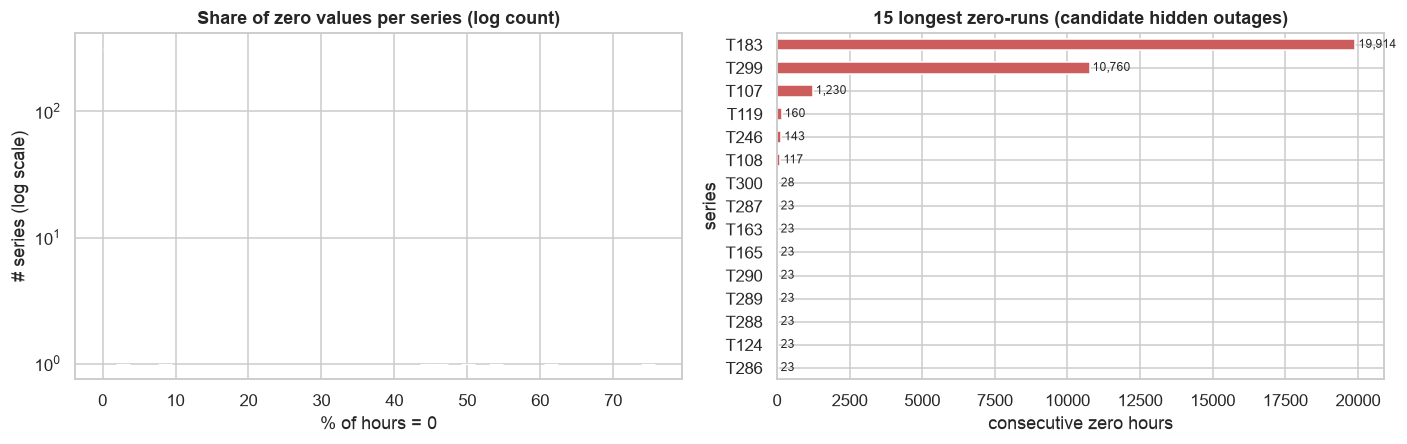

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))

# Left: zero-share distribution on a LOG count axis. On a linear axis the ~313 series with
# < 2% zeros form one tall bar and the handful of high-zero series (the ones we actually care
# about) are invisible in the tail. Log-y makes those rare bins (count 1-6) show up.
sns.histplot(quality["pct_zeros"], bins=40, ax=axes[0], color="steelblue", log_scale=(False, True))
axes[0].set(title="Share of zero values per series (log count)", xlabel="% of hours = 0",
            ylabel="# series (log scale)")

# Right: the actionable view -- rank the worst series by longest zero run (candidate hidden outages),
# which a histogram cannot show because only ~3 series have a run worth flagging.
top_runs = quality["longest_zero_run_h"].sort_values(ascending=False).head(15)
top_runs.iloc[::-1].plot.barh(ax=axes[1], color="indianred")
axes[1].set(title="15 longest zero-runs (candidate hidden outages)",
            xlabel="consecutive zero hours", ylabel="series")
for y, v in enumerate(top_runs.iloc[::-1].to_numpy()):
    axes[1].text(v, y, f" {int(v):,}", va="center", fontsize=8)
plt.tight_layout(); plt.show()


**Interpretation.** Zeros are the main data-quality concern here: because the header marks
the data as complete, any long zero run is effectively a *hidden gap* (a de-energized or
un-metered client). Series with large zero shares or long zero runs are flagged for special
handling — either exclusion, imputation, or at least awareness that their MASE denominator can
be inflated. This is logged for the preprocessing step in Phase 3.

## 5. Global value distribution

count      8,443,584.000
mean           2,538.792
std           15,027.570
min                0.000
p1                 0.000
p25              241.000
median           550.000
p75            1,387.000
p99           31,423.000
max          764,000.000
skew              22.239
kurtosis         633.963


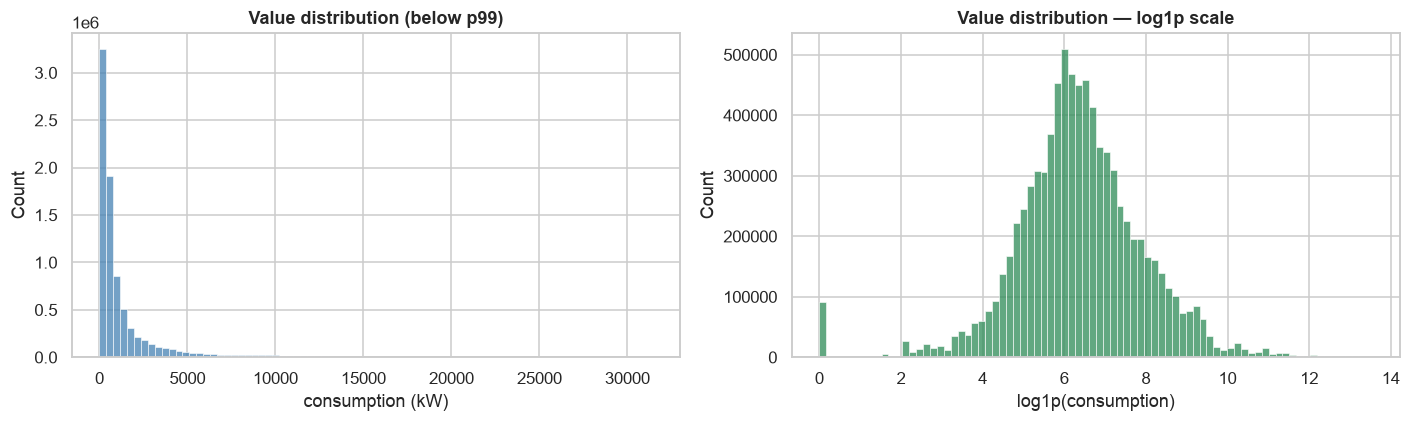

In [37]:
flat = wide.values.reshape(-1)
flat = flat[~np.isnan(flat)]
from scipy import stats as sps
desc = pd.Series({
    "count": flat.size, "mean": flat.mean(), "std": flat.std(),
    "min": flat.min(), "p1": np.percentile(flat, 1), "p25": np.percentile(flat, 25),
    "median": np.median(flat), "p75": np.percentile(flat, 75),
    "p99": np.percentile(flat, 99), "max": flat.max(),
    "skew": sps.skew(flat), "kurtosis": sps.kurtosis(flat),
})
print(desc.to_string())

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
sns.histplot(flat[flat < np.percentile(flat, 99)], bins=80, ax=axes[0], color="steelblue")
axes[0].set(title="Value distribution (below p99)", xlabel="consumption (kW)")
sns.histplot(np.log1p(flat), bins=80, ax=axes[1], color="seagreen")
axes[1].set(title="Value distribution — log1p scale", xlabel="log1p(consumption)")
plt.tight_layout(); plt.show()


**Interpretation.** The raw distribution is strongly right-skewed and heavy-tailed — expected
when 321 clients of very different sizes are pooled. On a `log1p` scale it becomes far more
symmetric, which suggests log-like or per-series scaling will stabilize training for the neural
models.

## 6. Per-series scale heterogeneity

This is arguably the most important property for a **global** model: if series live on wildly
different scales, a shared model must normalize per series (e.g. RevIN / instance normalization),
otherwise large clients dominate the loss.


In [38]:
series_stats = pd.DataFrame({
    "mean": wide.mean(),
    "std": wide.std(),
    "min": wide.min(),
    "median": wide.median(),
    "max": wide.max(),
})
series_stats["cv"] = series_stats["std"] / series_stats["mean"].replace(0, np.nan)
print("Ratio of largest to smallest series mean: "
      f"{series_stats['mean'].max() / series_stats['mean'].min():,.0f}x")
series_stats.describe()


Ratio of largest to smallest series mean: 18,869x


,mean,std,min,median,max,cv
count,321.000,321.000,321.000,321.000,321.000,321.000
mean,"2,538.792","1,139.744",2.928,"2,519.075","6,723.358",0.414
std,"12,479.287","8,336.701",7.242,"11,282.037","44,481.260",0.276
min,10.627,8.542,0.000,0.000,85.000,0.077
25%,288.346,105.848,0.000,290.000,691.000,0.286
50%,591.950,206.609,0.000,606.000,"1,317.000",0.332
75%,"1,425.516",522.724,4.000,"1,509.000","3,161.000",0.432
max,"200,529.125","146,054.611",64.000,"174,000.000","764,000.000",2.924


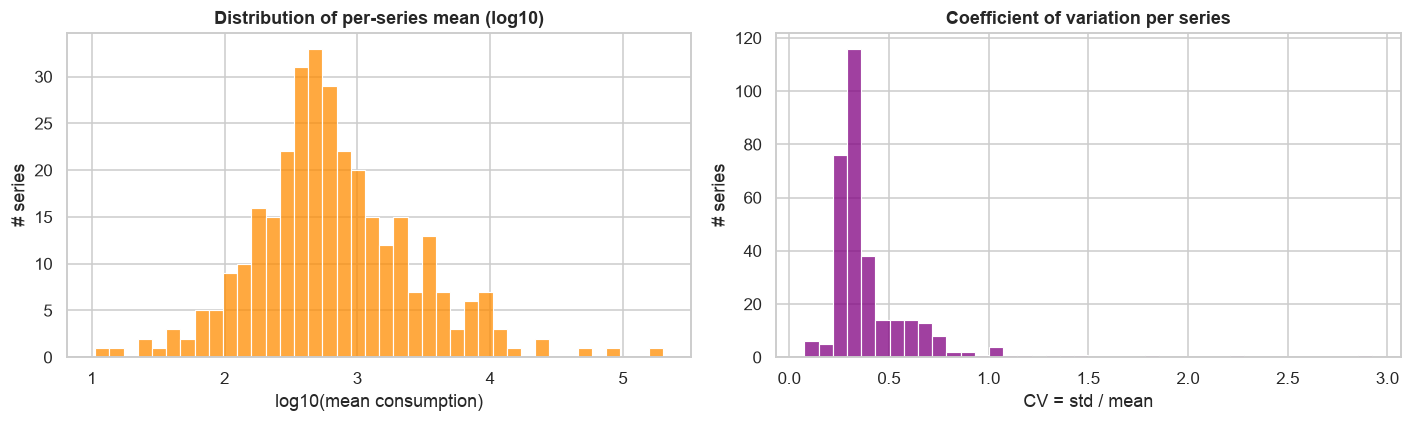

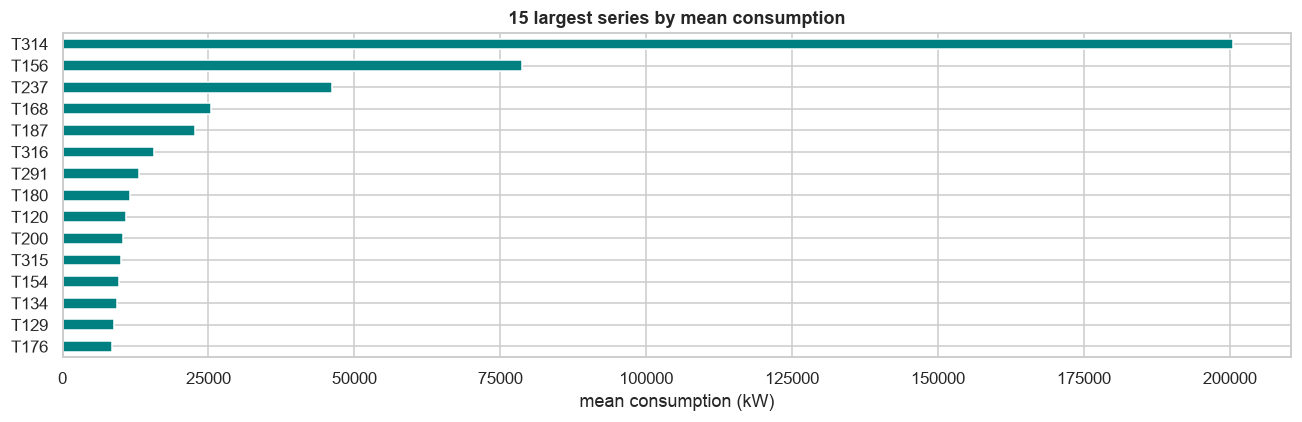

In [39]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
sns.histplot(np.log10(series_stats["mean"]), bins=40, ax=axes[0], color="darkorange")
axes[0].set(title="Distribution of per-series mean (log10)", xlabel="log10(mean consumption)",
            ylabel="# series")
sns.histplot(series_stats["cv"], bins=40, ax=axes[1], color="purple")
axes[1].set(title="Coefficient of variation per series", xlabel="CV = std / mean", ylabel="# series")
plt.tight_layout(); plt.show()

top = series_stats["mean"].sort_values(ascending=False).head(15)
fig, ax = plt.subplots(figsize=(12, 4))
top.iloc[::-1].plot.barh(ax=ax, color="teal")
ax.set(title="15 largest series by mean consumption", xlabel="mean consumption (kW)")
plt.tight_layout(); plt.show()


**Interpretation.** The per-series mean spans several orders of magnitude (see the
largest-to-smallest ratio printed above). **Per-series normalization is mandatory** for the
global neural models (PatchTST) and is also how Chronos internally scales each context window.
Classical per-series models (ETS/ARIMA) are naturally scale-invariant, so this mainly constrains
the deep-learning and foundation-model tracks.

## 7. Aggregate temporal dynamics

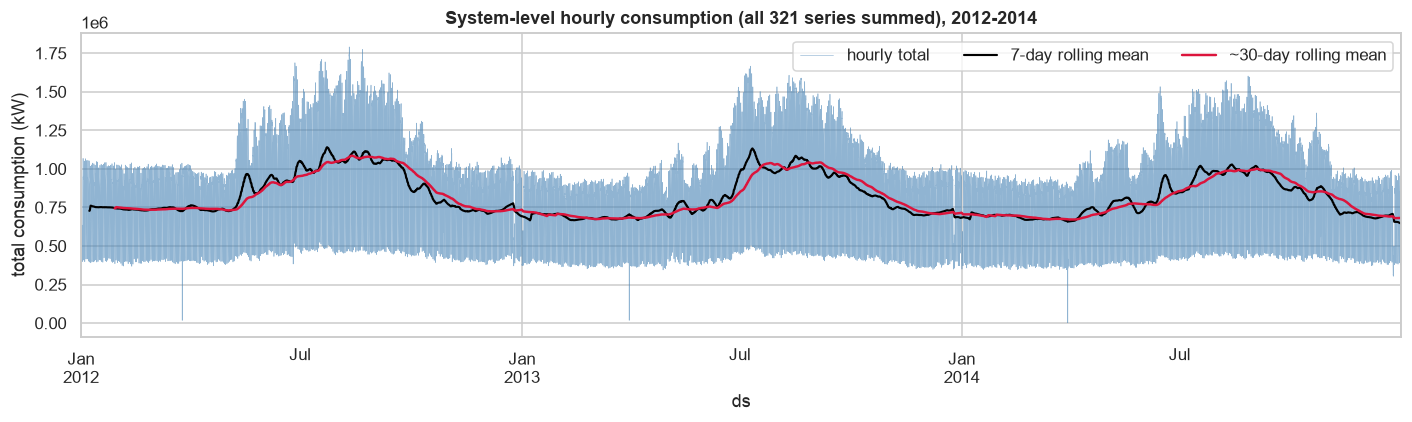

In [40]:
agg_total = wide.sum(axis=1)   # system-level load (legitimately scale-weighted)
agg_mean = wide.mean(axis=1)   # cross-series mean -- NOTE: scale-weighted, so it is ~dominated by the
                               # largest clients (top-10 ~= 53% of load). It is a fine proxy for
                               # "system behaviour" but NOT for a "typical" series. See §8b for the
                               # equal-weight, per-series view of seasonality.

fig, ax = plt.subplots(figsize=(13, 4))
agg_total.plot(ax=ax, lw=0.4, color="steelblue", alpha=0.6, label="hourly total")
agg_total.rolling(WEEKLY).mean().plot(ax=ax, color="black", lw=1.4, label="7-day rolling mean")
agg_total.rolling(WEEKLY * 4).mean().plot(ax=ax, color="crimson", lw=1.6, label="~30-day rolling mean")
ax.set(title="System-level hourly consumption (all 321 series summed), 2012-2014",
       ylabel="total consumption (kW)")
ax.legend(loc="upper right", ncol=3); plt.tight_layout(); plt.show()


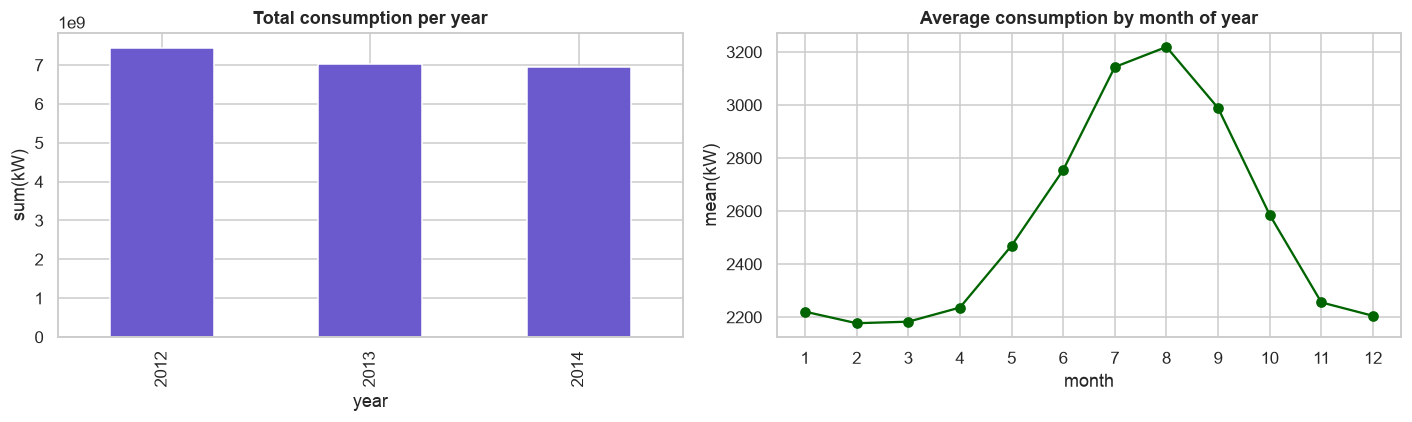

In [41]:
cal = pd.DataFrame({"total": agg_total, "mean": agg_mean}, index=wide.index)
cal["year"] = cal.index.year
cal["month"] = cal.index.month
cal["dow"] = cal.index.dayofweek       # 0=Mon
cal["hour"] = cal.index.hour
cal["is_weekend"] = cal["dow"] >= 5

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
cal.groupby("year")["total"].sum().plot.bar(ax=axes[0], color="slateblue")
axes[0].set(title="Total consumption per year", ylabel="sum(kW)", xlabel="year")
monthly = cal.groupby("month")["mean"].mean()
monthly.plot(ax=axes[1], marker="o", color="darkgreen")
axes[1].set(title="Average consumption by month of year", xlabel="month", ylabel="mean(kW)")
axes[1].set_xticks(range(1, 13))
plt.tight_layout(); plt.show()


**Interpretation.** The rolling means expose the **trend and annual seasonality**: consumption
rises in the cold/hot months and dips in shoulder seasons. Yearly totals show whether there is a
multi-year trend (growth/decline) the models must track. Both matter for choosing context length
and for deciding whether yearly seasonality is worth encoding (it is long relative to a 168h
horizon, so it mostly enters as slow trend).

## 8. Multiple-seasonality analysis

Electricity demand famously has **two strong periods**: the daily cycle (24h) and the weekly
cycle (168h, weekday vs weekend). We profile both and visualize their interaction.


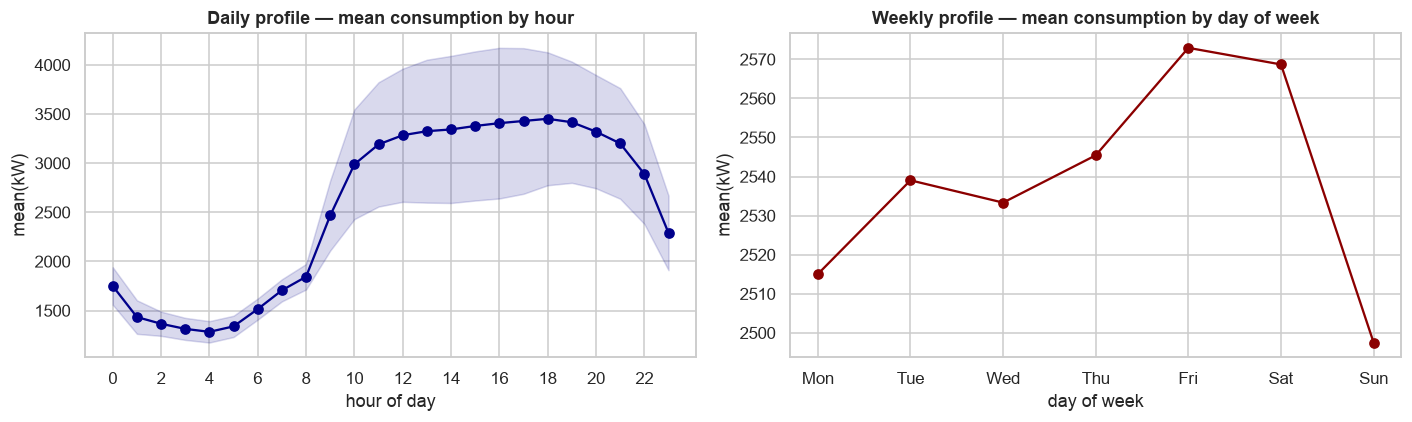

In [42]:
hour_profile = cal.groupby("hour")["mean"].mean()
hour_std = cal.groupby("hour")["mean"].std()
dow_profile = cal.groupby("dow")["mean"].mean()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(hour_profile.index, hour_profile.values, marker="o", color="darkblue")
axes[0].fill_between(hour_profile.index, hour_profile - hour_std, hour_profile + hour_std,
                     alpha=0.15, color="darkblue")
axes[0].set(title="Daily profile — mean consumption by hour", xlabel="hour of day",
            ylabel="mean(kW)", xticks=range(0, 24, 2))
dow_labels = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
axes[1].plot(dow_profile.index, dow_profile.values, marker="o", color="darkred")
axes[1].set(title="Weekly profile — mean consumption by day of week", xlabel="day of week",
            ylabel="mean(kW)")
axes[1].set_xticks(range(7)); axes[1].set_xticklabels(dow_labels)
plt.tight_layout(); plt.show()


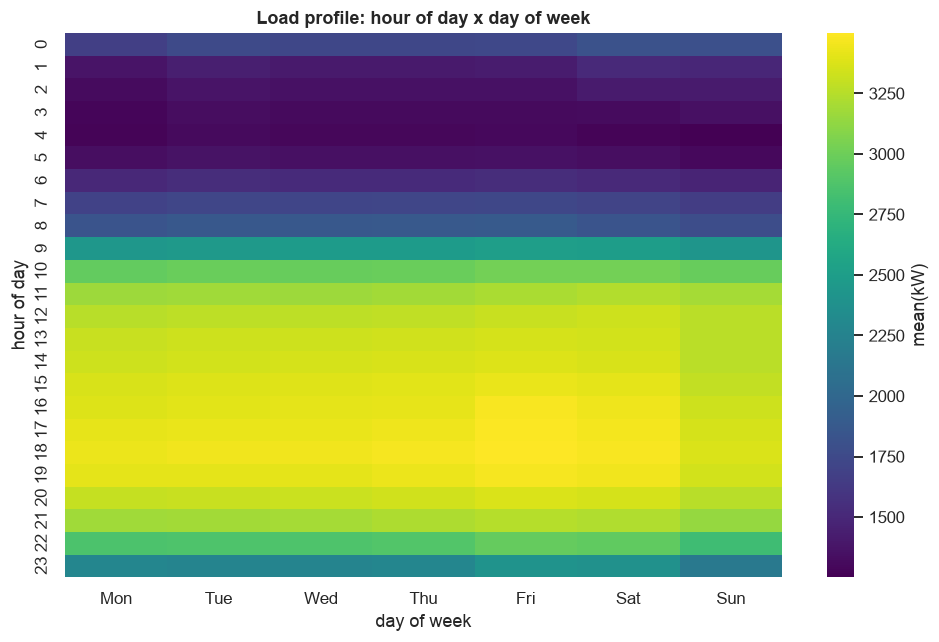

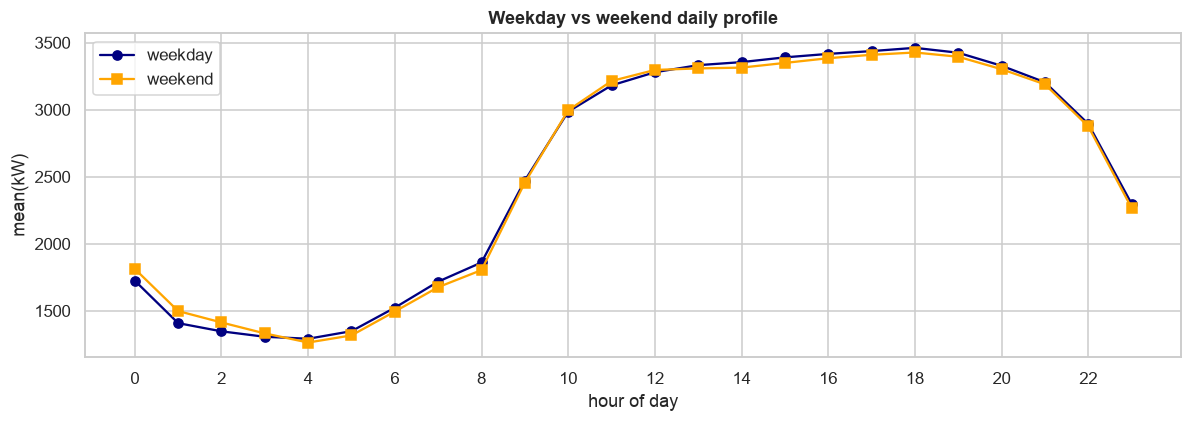

In [43]:
# Hour x day-of-week heatmap — the canonical load-profile fingerprint.
pivot = cal.pivot_table(index="hour", columns="dow", values="mean", aggfunc="mean")
pivot.columns = dow_labels
fig, ax = plt.subplots(figsize=(9, 6))
sns.heatmap(pivot, cmap="viridis", ax=ax, cbar_kws={"label": "mean(kW)"})
ax.set(title="Load profile: hour of day x day of week", xlabel="day of week", ylabel="hour of day")
plt.tight_layout(); plt.show()

# Weekday vs weekend overlay
wd = cal[~cal["is_weekend"]].groupby("hour")["mean"].mean()
we = cal[cal["is_weekend"]].groupby("hour")["mean"].mean()
fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(wd.index, wd.values, marker="o", label="weekday", color="navy")
ax.plot(we.index, we.values, marker="s", label="weekend", color="orange")
ax.set(title="Weekday vs weekend daily profile", xlabel="hour of day", ylabel="mean(kW)",
       xticks=range(0, 24, 2))
ax.legend(); plt.tight_layout(); plt.show()


**Interpretation.** The heatmap makes the two seasonalities explicit: a clear intraday shape
that shifts between weekdays and weekends. This confirms both **24h and 168h** are real periods —
which is exactly what MSTL (§10) will decompose and what motivates a context window of at least a
few full weeks so the model can see the weekly pattern.

### 8b. Per-series seasonal strength — is weekly seasonality real, or an aggregate artifact?

The profiles above are computed on the **scale-weighted** aggregate, which a handful of very large
clients dominate (top-10 series ≈ 53% of total load). That aggregate can *hide* weekly structure:
different clients peak on different days and partly cancel out. Here we measure — **for every series
independently, with equal weight** — how much of its variance is explained by the daily (hour-of-day)
profile versus the extra weekly (weekday/weekend) modulation.

Median daily  seasonal strength : 0.696
Median weekly seasonal strength : 0.008
Series with weekly strength > 0.05 : 70 / 321
Series with weekly strength > 0.10 : 43 / 321


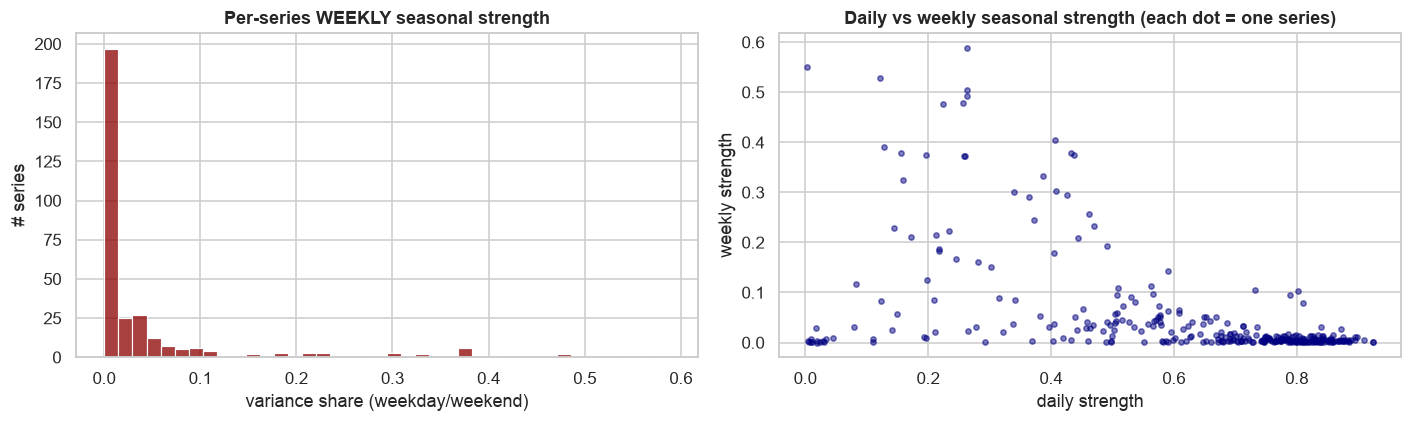

In [44]:
# Orthogonal per-series variance decomposition: daily (hour-of-day) vs the extra weekly
# (weekday/weekend) modulation. Every series counts equally, unlike the scale-weighted aggregate.
#   daily  share = var(hour-of-day mean profile) / var(series)
#   weekly share = var(hour-of-week profile - hour-of-day profile) / var(series)
# The two parts are orthogonal by construction, so they are additive (both <= total seasonal share).
hour_idx = wide.index.hour.to_numpy()
how_idx = wide.index.dayofweek.to_numpy() * 24 + hour_idx        # hour-of-week, 0..167

def seasonal_strength(col):
    y = col.to_numpy(dtype="float64")
    v = y.var()
    if not np.isfinite(v) or v == 0:
        return pd.Series({"daily": np.nan, "weekly": np.nan})
    s = pd.Series(y)
    dprof = s.groupby(hour_idx).transform("mean").to_numpy()     # hour-of-day mean profile
    wprof = s.groupby(how_idx).transform("mean").to_numpy()      # hour-of-week mean profile
    return pd.Series({"daily": dprof.var() / v, "weekly": (wprof - dprof).var() / v})

strength = wide.apply(seasonal_strength).T                       # rows=series, cols=[daily, weekly]
print(f"Median daily  seasonal strength : {strength['daily'].median():.3f}")
print(f"Median weekly seasonal strength : {strength['weekly'].median():.3f}")
print(f"Series with weekly strength > 0.05 : {int((strength['weekly'] > 0.05).sum())} / {len(strength)}")
print(f"Series with weekly strength > 0.10 : {int((strength['weekly'] > 0.10).sum())} / {len(strength)}")

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
sns.histplot(strength["weekly"].dropna(), bins=40, ax=axes[0], color="darkred")
axes[0].set(title="Per-series WEEKLY seasonal strength", xlabel="variance share (weekday/weekend)",
            ylabel="# series")
axes[1].scatter(strength["daily"], strength["weekly"], s=12, alpha=0.5, color="navy")
axes[1].set(title="Daily vs weekly seasonal strength (each dot = one series)",
            xlabel="daily strength", ylabel="weekly strength")
plt.tight_layout(); plt.show()


**Interpretation.** Daily seasonality is **universal and strong** — nearly every series is well
explained by its hour-of-day profile. Weekly seasonality is **heterogeneous**: negligible for many
clients yet substantial for a distinct subset (those with a clear weekday/weekend contrast). This
reconciles the near-zero weekly share of the scale-weighted aggregate MSTL (§10, ≈ 0.3%) with the
genuine weekly patterns that exist in individual series — they average out globally, they do not
disappear. Implications: (1) a **global** model still needs a context window of **≥ 1 week** so it can
serve the weekly-patterned subset, even though the aggregate looks weekly-flat; (2) Phase 7 error
analysis should **stratify by weekly strength**, since the weekly-strong series are where a
seasonal-naive(m=168) baseline is hardest to beat.

## 9. Autocorrelation (ACF / PACF)

ACF/PACF quantify the seasonality visually seen above and, importantly, tell us **which seasonal
period `m` to use for MASE** (the scale-free error metric). We compute on the average-client
series to keep it representative and readable.


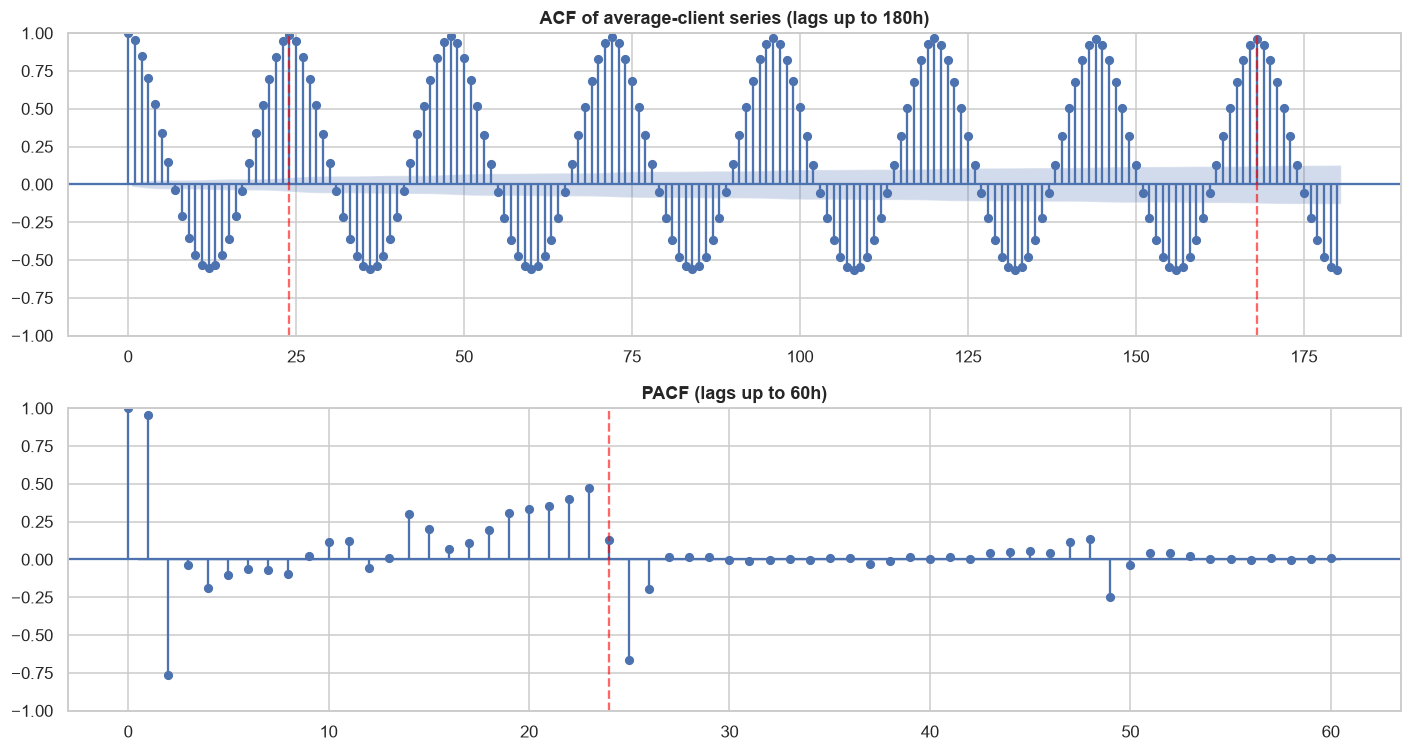

In [45]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

fig, axes = plt.subplots(2, 1, figsize=(13, 7))
plot_acf(agg_mean, lags=WEEKLY + 12, ax=axes[0])
axes[0].set(title="ACF of average-client series (lags up to 180h)")
for lag in (DAILY, WEEKLY):
    axes[0].axvline(lag, color="red", ls="--", alpha=0.6)
plot_pacf(agg_mean, lags=60, method="ywm", ax=axes[1])
axes[1].set(title="PACF (lags up to 60h)")
axes[1].axvline(DAILY, color="red", ls="--", alpha=0.6)
plt.tight_layout(); plt.show()


**Interpretation.** Strong ACF spikes at multiples of **24h** and a prominent bump at **168h**
confirm the daily and weekly cycles. We adopt **m = 24** as the primary seasonal period for MASE
(daily), which is the standard choice for hourly electricity in the Monash benchmark. The slow
decay of the ACF also signals non-stationarity in the mean, examined next.

## 10. Seasonal-trend decomposition (STL / MSTL)

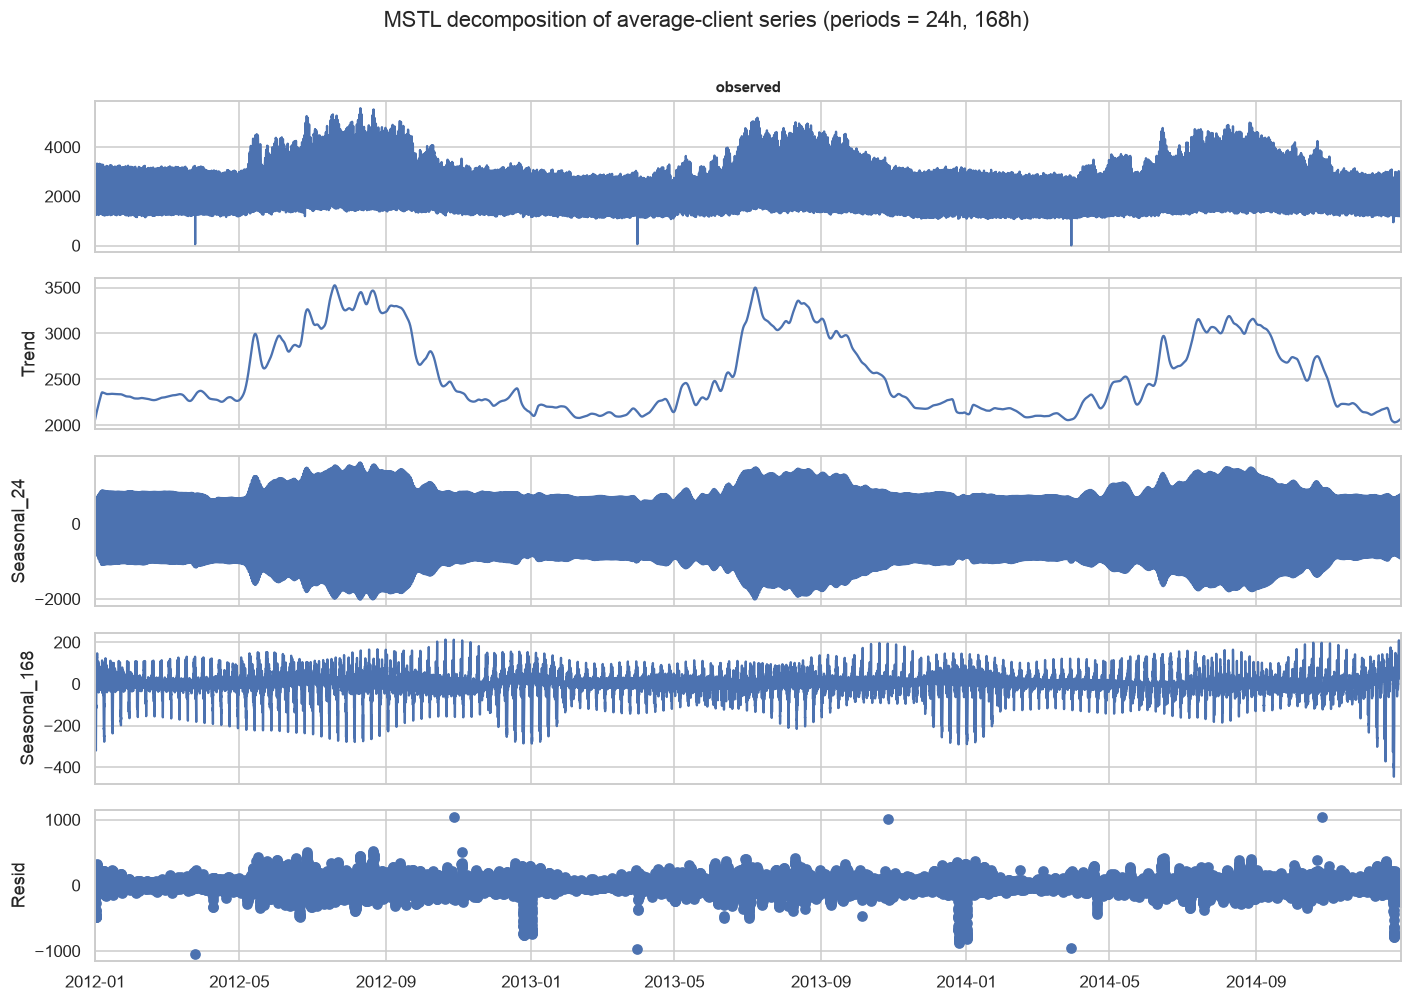

,variance_share_%
trend,16.900
seasonal_24,81.800
seasonal_168,0.300
resid,1.000


In [46]:
from statsmodels.tsa.seasonal import STL, MSTL

# MSTL handles multiple seasonalities simultaneously (24h and 168h).
mstl = MSTL(agg_mean, periods=(DAILY, WEEKLY)).fit()
fig = mstl.plot()
fig.set_size_inches(13, 9)
for a in fig.axes:
    a.set_title(a.get_title(), fontsize=10)
plt.suptitle("MSTL decomposition of average-client series (periods = 24h, 168h)", y=1.01)
plt.tight_layout(); plt.show()

# Variance share explained by each component (how much structure is seasonal vs residual).
comp_var = pd.Series({
    "trend": np.nanvar(mstl.trend),
    "seasonal_24": np.nanvar(mstl.seasonal["seasonal_24"]),
    "seasonal_168": np.nanvar(mstl.seasonal["seasonal_168"]),
    "resid": np.nanvar(mstl.resid),
})
(100 * comp_var / comp_var.sum()).round(1).rename("variance_share_%").to_frame()


**Interpretation.** MSTL separates a slow trend, the 24h and 168h seasonal components, and a residual.
The variance-share table quantifies how much of the signal is *predictable structure* (trend +
seasonality) versus residual noise — a rough upper bound on the gain a model can make over
seasonal-naive. **Caveat:** this runs on the **scale-weighted aggregate**, which the largest clients
dominate (top-10 ≈ 53% of load). So the 24h share is biased toward big-client behavior, and the tiny
weekly share (≈ 0.3%) *understates* per-series weekly seasonality — a subset of series has clear weekly
structure that cancels out in the aggregate (see §8b). Read these shares as "big-client aggregate,"
not "typical series."

## 11. Stationarity tests (ADF / KPSS)

We combine ADF (H0: unit root / non-stationary) and KPSS (H0: stationary). Running both on a
random sample of individual series tells us whether differencing/detrending is broadly needed —
relevant mostly for the classical ARIMA track.


In [47]:
from statsmodels.tsa.stattools import adfuller, kpss

def stationarity(series):
    s = pd.Series(series).dropna()
    out = {}
    try:
        out["adf_p"] = adfuller(s, autolag="AIC")[1]
    except Exception:
        out["adf_p"] = np.nan
    try:
        with warnings.catch_warnings():
            # KPSS p-value is looked up in a capped table; for strongly non-stationary
            # series it returns "p < 0.01" with an InterpolationWarning. That is expected
            # here, so we silence the (very repetitive) warning rather than spam the log.
            warnings.simplefilter("ignore")
            out["kpss_p"] = kpss(s, regression="c", nlags="auto")[1]
    except Exception:
        out["kpss_p"] = np.nan
    return out

sample_ids = pd.Index(series_names).to_series().sample(30, random_state=RANDOM_SEED).tolist()
rows = {sid: stationarity(wide[sid]) for sid in sample_ids}
rows["__aggregate_mean__"] = stationarity(agg_mean)
stat_df = pd.DataFrame(rows).T
stat_df["adf_stationary(p<0.05)"] = stat_df["adf_p"] < 0.05
stat_df["kpss_stationary(p>0.05)"] = stat_df["kpss_p"] > 0.05

print(f"ADF says stationary : {stat_df['adf_stationary(p<0.05)'].mean()*100:.0f}% of sampled series")
print(f"KPSS says stationary: {stat_df['kpss_stationary(p>0.05)'].mean()*100:.0f}% of sampled series")
stat_df.head(12)


ADF says stationary : 94% of sampled series
KPSS says stationary: 0% of sampled series


,adf_p,kpss_p,adf_stationary(p<0.05),kpss_stationary(p>0.05)
T174,0.000,0.010,True,False
T133,0.000,0.010,True,False
T198,0.000,0.010,True,False
T10,0.000,0.010,True,False
T105,0.000,0.010,True,False
T120,0.000,0.010,True,False
T251,0.000,0.010,True,False
T159,0.000,0.010,True,False
T227,0.000,0.010,True,False
T311,0.000,0.010,True,False


**Interpretation.** ADF typically rejects the unit root for most series (they are dominated by
strong stationary seasonality), while KPSS often flags level/trend drift — the two disagreeing is
the classic signature of a *stationary-around-a-slowly-changing-level* process. Practically:
`AutoARIMA` should difference conservatively, and the neural/foundation models handle the drift via
per-window normalization.

## 12. Outliers & anomalies

Median per-series outlier rate (3xIQR): 0.00%
Series with >2% outliers             : 10


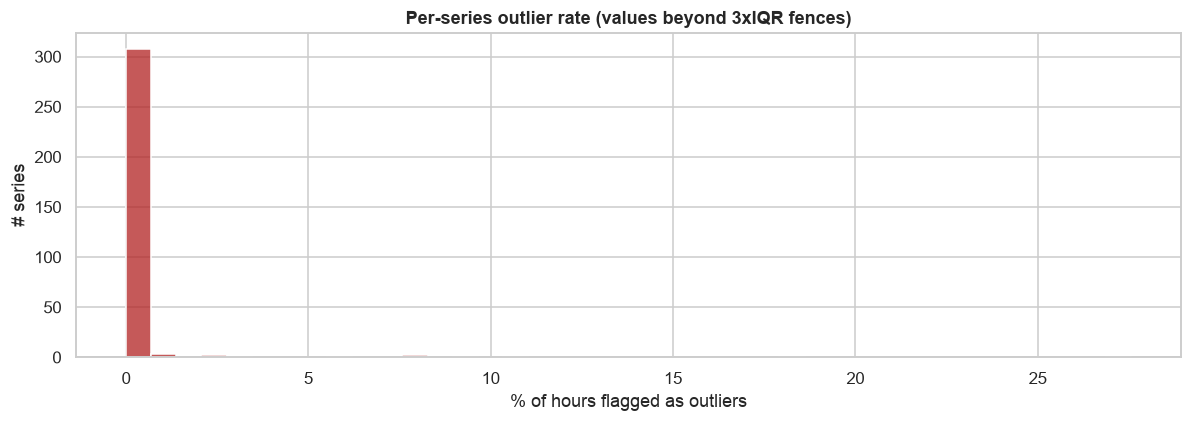

In [48]:
# Per-series robust outlier rate via IQR fences on non-zero values.
def outlier_rate(col):
    v = col[col > 0].to_numpy()
    if v.size < 10:
        return np.nan
    q1, q3 = np.percentile(v, [25, 75])
    iqr = q3 - q1
    lo, hi = q1 - 3 * iqr, q3 + 3 * iqr
    return float(((v < lo) | (v > hi)).mean() * 100)

out_rate = wide.apply(outlier_rate, axis=0)
print(f"Median per-series outlier rate (3xIQR): {out_rate.median():.2f}%")
print(f"Series with >2% outliers             : {(out_rate > 2).sum()}")

fig, ax = plt.subplots(figsize=(11, 4))
sns.histplot(out_rate.dropna(), bins=40, color="firebrick", ax=ax)
ax.set(title="Per-series outlier rate (values beyond 3xIQR fences)",
       xlabel="% of hours flagged as outliers", ylabel="# series")
plt.tight_layout(); plt.show()


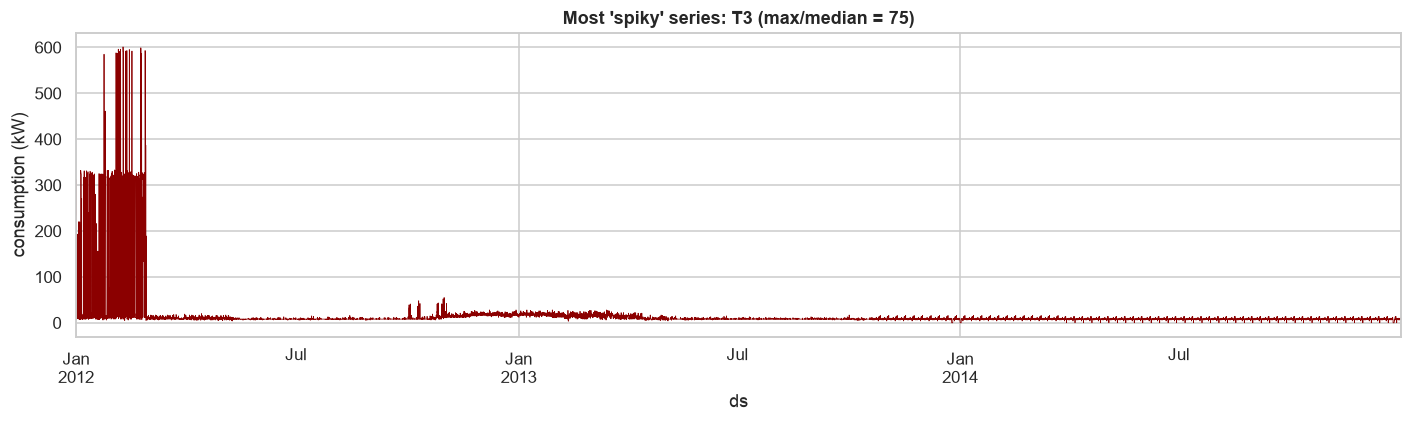

In [49]:
# Visualize the series with the most extreme single spike (max / median ratio).
spikiness = (wide.max() / wide.median().replace(0, np.nan)).sort_values(ascending=False)
spiky_id = spikiness.index[0]
fig, ax = plt.subplots(figsize=(13, 4))
wide[spiky_id].plot(ax=ax, lw=0.5, color="darkred")
ax.set(title=f"Most 'spiky' series: {spiky_id} (max/median = {spikiness.iloc[0]:,.0f})",
       ylabel="consumption (kW)")
plt.tight_layout(); plt.show()


**Interpretation.** Most series have a low outlier rate, but a subset shows sharp spikes
(demand surges or metering artifacts). These extremes inflate RMSE/MAE more than MASE/sMAPE, which
is one reason we report **multiple metrics** and lean on the scale-free MASE for ranking models.

## 13. Cross-series structure (correlation & clustering)

If series share shape, a single **global** model (one model, all series) can borrow strength
across them — the premise behind PatchTST-global and Chronos. We test this two ways: correlation
of daily totals, and clustering of the normalized daily load shapes.


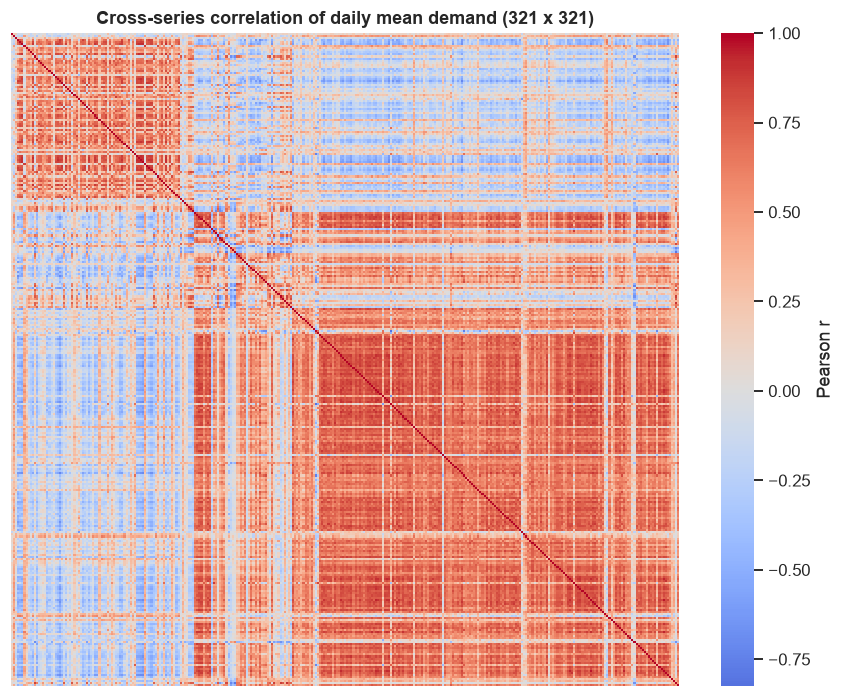

Mean pairwise correlation : 0.250
Share of pairs with r>0.5 : 16.8%


In [50]:
# Correlation of daily-aggregated demand across series.
daily = wide.resample("D").mean()
corr = daily.corr()
fig, ax = plt.subplots(figsize=(8, 6.5))
sns.heatmap(corr, cmap="coolwarm", center=0, ax=ax, cbar_kws={"label": "Pearson r"},
            xticklabels=False, yticklabels=False)
ax.set(title="Cross-series correlation of daily mean demand (321 x 321)")
plt.tight_layout(); plt.show()

upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool)).stack()
print(f"Mean pairwise correlation : {upper.mean():.3f}")
print(f"Share of pairs with r>0.5 : {(upper > 0.5).mean()*100:.1f}%")


Cluster sizes:
 cluster
0     89
1     68
2    155
3      9


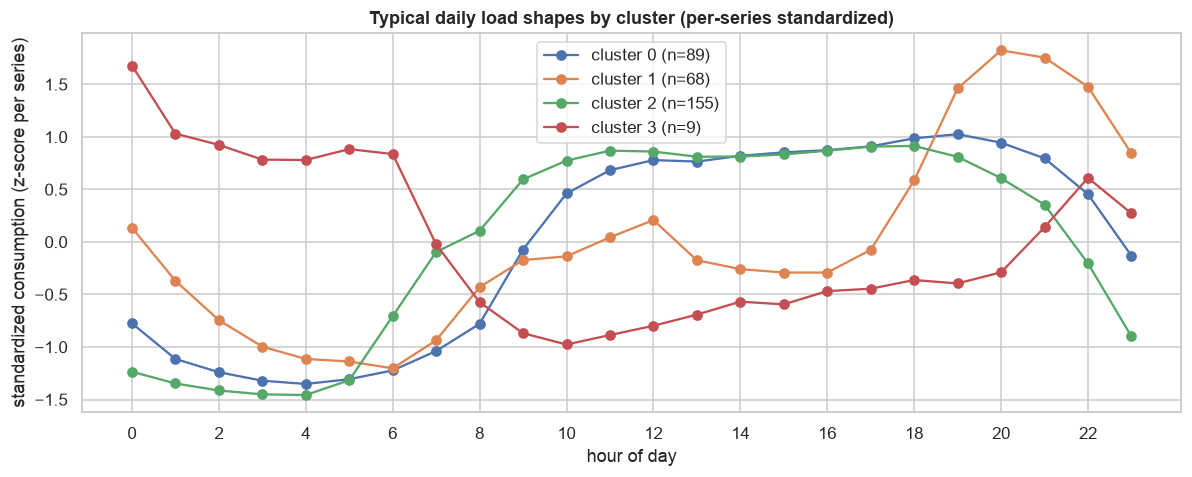

In [51]:
# Cluster series by their daily *shape* (321 x 24 feature matrix).
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

hod = wide.groupby(wide.index.hour).mean().T   # rows=series, cols=hour 0..23

# IMPORTANT: normalize each SERIES (row) so clustering keys on shape, not scale.
# StandardScaler standardizes *columns*; on the raw profiles that leaves the 18,869x scale
# spread in and collapses everything into one big cluster + a few giant-series singletons
# (i.e. it clusters by size). Z-scoring each row removes level and isolates the daily shape.
hod_shape = hod.sub(hod.mean(axis=1), axis=0).div(hod.std(axis=1) + 1e-9, axis=0)

K = 4
km = KMeans(n_clusters=K, random_state=RANDOM_SEED, n_init=10).fit(hod_shape.values)
labels = pd.Series(km.labels_, index=hod.index, name="cluster")
print("Cluster sizes:\n", labels.value_counts().sort_index().to_string())

fig, ax = plt.subplots(figsize=(11, 4.5))
centers = pd.DataFrame(km.cluster_centers_, columns=range(24))
for k in range(K):
    ax.plot(range(24), centers.loc[k], marker="o", label=f"cluster {k} (n={ (labels==k).sum() })")
ax.set(title="Typical daily load shapes by cluster (per-series standardized)", xlabel="hour of day",
       ylabel="standardized consumption (z-score per series)", xticks=range(0, 24, 2))
ax.legend(); plt.tight_layout(); plt.show()


**Interpretation.** The clustering is run on **per-series–standardized** daily shapes, so it keys on
*profile shape* rather than scale. (Clustering the raw / column-standardized profiles instead collapses
into one dominant cluster plus a few giant-series singletons — that is scale, not shape.) On the
shape-normalized features the series split into a few genuine daily archetypes (e.g. a pronounced
evening-peak profile vs. a flatter round-the-clock one). Combined with the *moderate* positive pairwise
correlation (mean r ≈ 0.25; ~17% of pairs r > 0.5), this says the series are **related but not
identical** — the ideal setting for a global model that shares structure across series while still
needing per-series normalization for scale. The shape clusters are useful later for stratified error
analysis (Phase 7).

## 14. Calendar effects

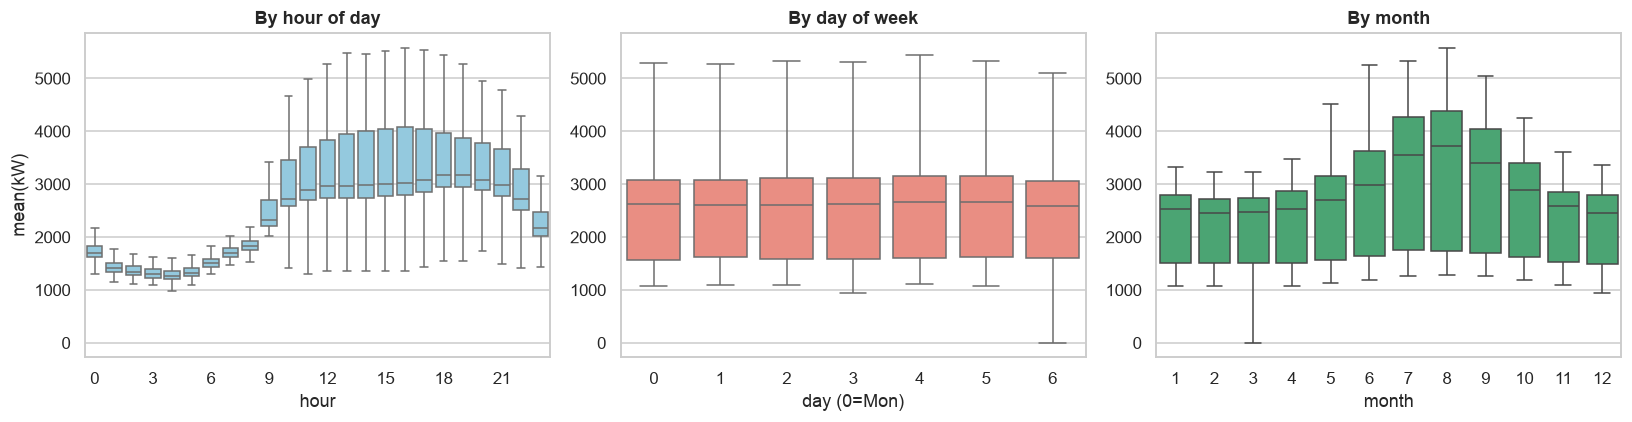

Weekend mean demand is -0.3% relative to weekdays.


In [52]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
sns.boxplot(data=cal, x="hour", y="mean", ax=axes[0], color="skyblue", fliersize=0)
axes[0].set(title="By hour of day", xlabel="hour", ylabel="mean(kW)")
axes[0].set_xticks(range(0, 24, 3))
sns.boxplot(data=cal, x="dow", y="mean", ax=axes[1], color="salmon", fliersize=0)
axes[1].set(title="By day of week", xlabel="day (0=Mon)", ylabel="")
sns.boxplot(data=cal, x="month", y="mean", ax=axes[2], color="mediumseagreen", fliersize=0)
axes[2].set(title="By month", xlabel="month", ylabel="")
plt.tight_layout(); plt.show()

weekend_effect = 100 * (cal.loc[cal.is_weekend, "mean"].mean() /
                        cal.loc[~cal.is_weekend, "mean"].mean() - 1)
print(f"Weekend mean demand is {weekend_effect:+.1f}% relative to weekdays.")


**Interpretation.** Hour-of-day, day-of-week and month all shift the demand distribution, so
**calendar features** (hour, day-of-week, month, is_weekend, holidays) are strong, cheap predictors.
They will be used directly by the LightGBM global baseline and as exogenous inputs where the neural
models support them.

## 15. Forecasting-readiness summary

**Data facts (confirmed):**
- 321 hourly series, 2012-01-01 -> 2014-12-31, 26,304 steps each, gap-free, equal length.
- No explicit NaNs, but zeros/long zero-runs act as hidden outages in a subset of series.
- Series scales span several orders of magnitude (18,869x; heavy right-skew).

**Structure (confirmed):**
- **Daily (24h)** seasonality is strong and effectively universal across series.
- **Weekly (168h)** seasonality is real but *heterogeneous* — strong for a subset of series (clear
  weekday/weekend contrast), negligible for many others — so it nearly cancels in the scale-weighted
  aggregate (§8b, §10). It is a per-series property, not an aggregate one.
- Slow annual trend on top of the seasonal structure.
- Series are related (moderate positive correlation, mean r ≈ 0.25) and fall into a few distinct daily
  **shape** archetypes once normalized per series (§13).
- Mostly stationary around a slowly drifting level (§11).

**Modeling decisions this EDA supports:**

| Decision | Choice | Evidence |
|---|---|---|
| Task framing | Global multi-series forecasting | §6, §13 — related series, shared shapes |
| Horizon `H` | 168 h (1 week) | Monash standard; weekly seasonality in a subset (§8b) |
| Context length | >= 1 week (168 h) minimum; 2-3 weeks preferred | span the 168h cycle for the weekly-patterned subset (§8b) |
| Normalization | Per-series / instance (RevIN) | §5, §6 — huge scale spread, skew |
| MASE seasonality `m` | 24 (daily) | §9 dominant ACF period, universal across series |
| Metrics | MASE + sMAPE + RMSE + WQL/CRPS | §12 — spikes; report scale-free + probabilistic |
| Split | Chronological; last 168h test, prev 168h val | avoids leakage (ROADMAP Phase 3) |
| Data cleaning | Flag/handle long zero-runs & spikes | §4, §12 |
| Error analysis | Stratify by daily/weekly strength, cluster, scale | §8b, §12, §13 |

**Artifacts produced:** tidy long-format Parquet at `data/interim/electricity_hourly_long.parquet`
for the modeling phases (statsforecast / neuralforecast / chronos).

Next step -> **Phase 3: Evaluation framework** (backtest harness + metrics), then baselines.